<a href="https://colab.research.google.com/github/BhavyaKyasani/Hospital-Command-Center-Analysis/blob/main/Operation_Theatre.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set(font_scale=1)

import warnings
warnings.filterwarnings("ignore")

In [ ]:
path = "/content/Operation_theatre_dataset_FINAL_3000 (1).csv"

df = pd.read_csv(path)

In [ ]:
print("Rows and Columns:", df.shape)

Rows and Columns: (3000, 8)


In [ ]:
print("First 5 Rows")
display(df.head())

print("Last 5 Rows")
display(df.tail())

First 5 Rows


,Surgery_ID,Surgery_Type,Scheduled_Time,Actual_Start_Time,Delay_Time,Surgeon,OT_Room,Equipment_Used
0,SURG001,Cardiothoracic Surgery,2026-05-03 17:05,2026-05-03 17:07,2,Dr. Arjun,OT-1,ECG Monitor
1,SURG002,Orthopedic Surgery,2026-05-01 06:58,2026-05-01 08:17,79,Dr. Meera,OT-1,Surgical Lights
2,SURG003,General Surgery,2026-05-05 09:53,2026-05-05 11:17,84,Dr. Kavitha,OT-4,Surgical Lights
3,SURG004,General Surgery,2026-05-08 18:05,2026-05-08 18:54,49,Dr. Rohit,OT-4,Anesthesia Machine
4,SURG005,Neurosurgery,2026-05-07 03:19,2026-05-07 04:48,89,Dr. Arjun,OT-2,ECG Monitor


Last 5 Rows


,Surgery_ID,Surgery_Type,Scheduled_Time,Actual_Start_Time,Delay_Time,Surgeon,OT_Room,Equipment_Used
2995,SURG2996,General Surgery,2026-11-28 12:21,2026-11-28 13:05,44,Dr. Sanjay,OT-3,Anesthesia Machine
2996,SURG2997,General Surgery,2026-11-28 14:47,2026-11-28 15:52,65,Dr. Rohit,OT-1,Surgical Lights
2997,SURG2998,General Surgery,2026-11-28 17:34,2026-11-28 18:50,76,Dr. Sanjay,OT-1,Surgical Lights
2998,SURG2999,General Surgery,2026-11-28 18:59,2026-11-28 20:23,84,Dr. Meera,OT-4,Anesthesia Machine
2999,SURG3000,Neurosurgery,2026-11-28 20:13,2026-11-28 20:53,40,Dr. Kavitha,OT-3,Microscope


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Surgery_ID         3000 non-null   object
 1   Surgery_Type       3000 non-null   object
 2   Scheduled_Time     3000 non-null   object
 3   Actual_Start_Time  3000 non-null   object
 4   Delay_Time         3000 non-null   int64 
 5   Surgeon            3000 non-null   object
 6   OT_Room            3000 non-null   object
 7   Equipment_Used     3000 non-null   object
dtypes: int64(1), object(7)
memory usage: 187.6+ KB


In [ ]:
print(df.dtypes)

Surgery_ID           object
Surgery_Type         object
Scheduled_Time       object
Actual_Start_Time    object
Delay_Time            int64
Surgeon              object
OT_Room              object
Equipment_Used       object
dtype: object


In [ ]:
display(df.describe(include='all'))

,Surgery_ID,Surgery_Type,Scheduled_Time,Actual_Start_Time,Delay_Time,Surgeon,OT_Room,Equipment_Used
count,3000,3000,3000,3000,3000.000000,3000,3000,3000
unique,3000,5,2997,2994,NaN,5,4,10
top,SURG3000,General Surgery,2026-05-04 21:22,2026-09-01 05:47,NaN,Dr. Arjun,OT-3,Anesthesia Machine
freq,1,629,2,2,NaN,850,761,591
mean,NaN,NaN,NaN,NaN,44.938000,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,26.657451,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,21.000000,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,45.000000,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,69.000000,NaN,NaN,NaN


Missing Values:
Surgery_ID           0
Surgery_Type         0
Scheduled_Time       0
Actual_Start_Time    0
Delay_Time           0
Surgeon              0
OT_Room              0
Equipment_Used       0
dtype: int64


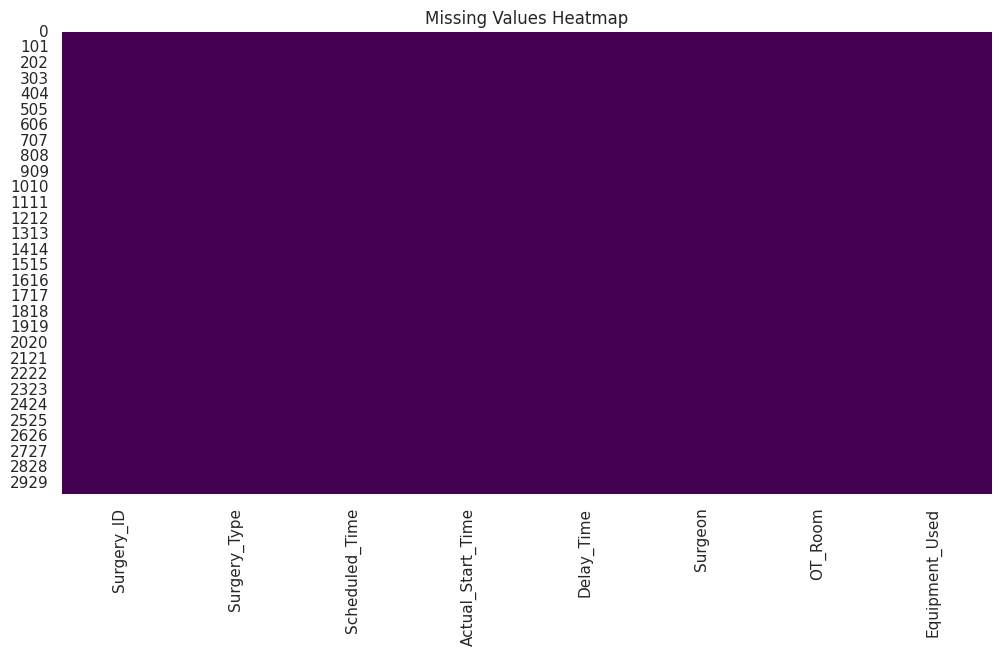

In [ ]:
missing = df.isnull().sum()

print("Missing Values:")
print(missing)

plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

In [ ]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [ ]:
unique = pd.DataFrame({
    "Column": df.columns,
    "Unique Values": df.nunique().values
})

display(unique)

,Column,Unique Values
0,Surgery_ID,3000
1,Surgery_Type,5
2,Scheduled_Time,2997
3,Actual_Start_Time,2994
4,Delay_Time,91
5,Surgeon,5
6,OT_Room,4
7,Equipment_Used,10


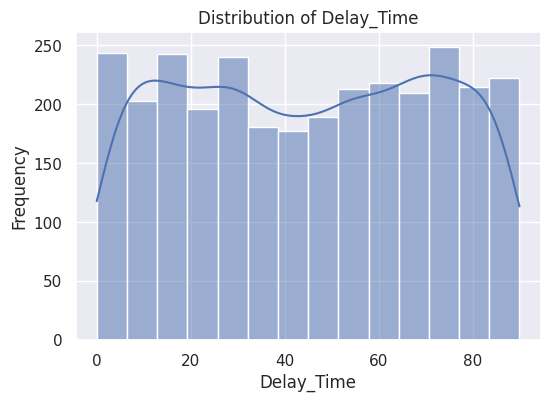

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

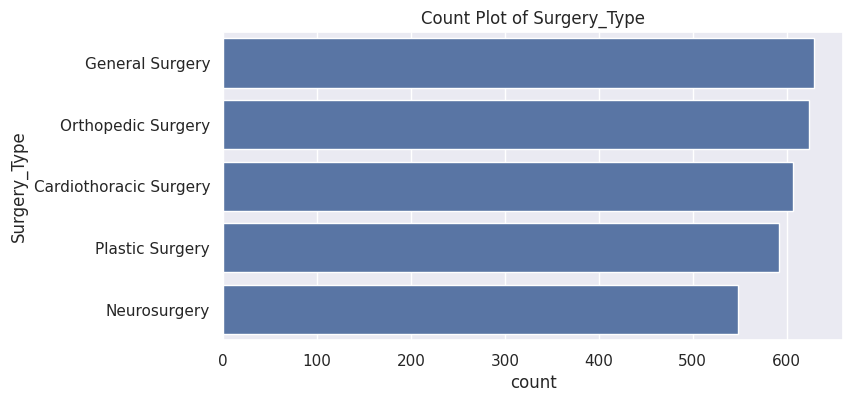

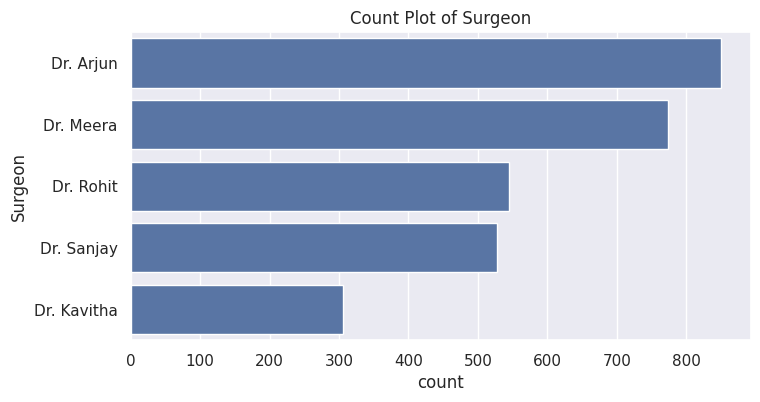

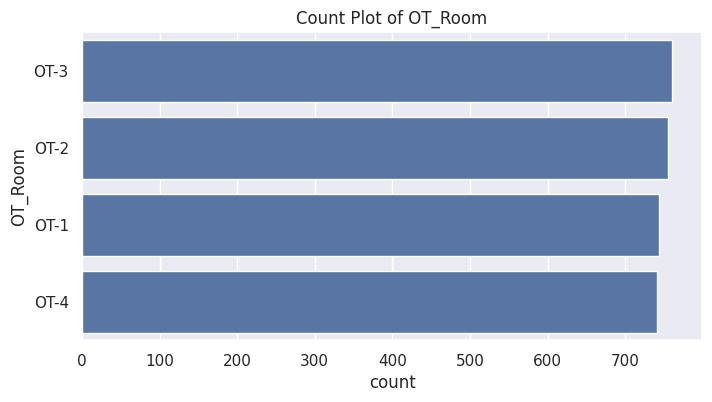

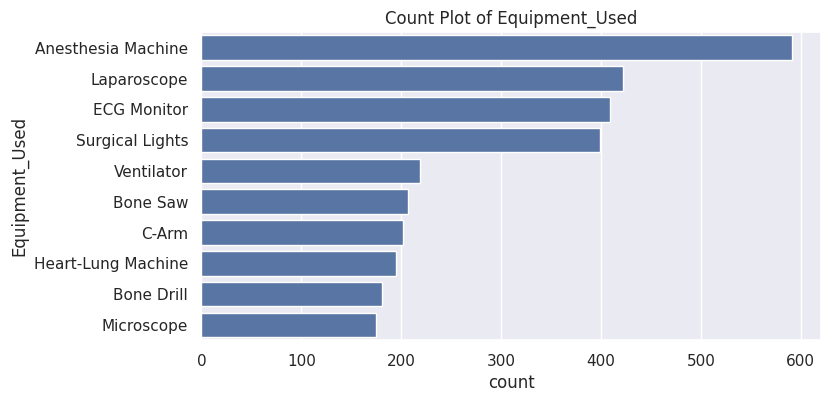

In [ ]:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    if df[col].nunique() <= 20:
        plt.figure(figsize=(8,4))
        sns.countplot(y=df[col], order=df[col].value_counts().index)
        plt.title(f"Count Plot of {col}")
        plt.show()

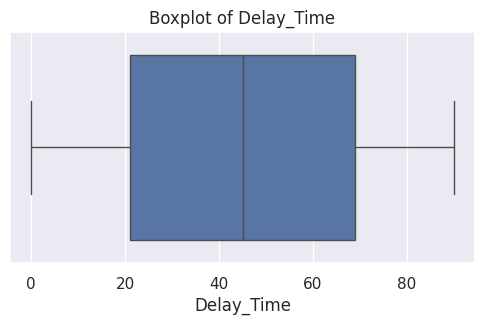

In [ ]:
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

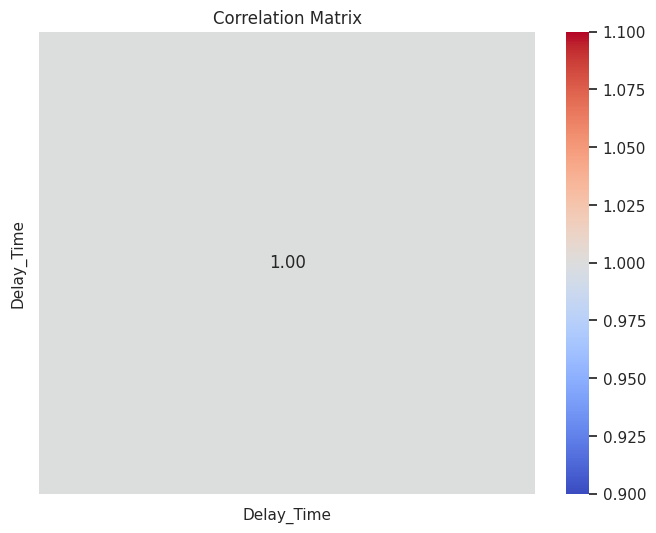

In [ ]:
corr = df[num_cols].corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [ ]:
clean_df = df.drop_duplicates()

clean_df.to_csv("/content/Operation_theatre_dataset_FINAL_3000_cleaned.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.
